# Choosing the pilot ward: Ntabankulu

`pilot.ipynb` runs the siting problem in a ward picked by hand. This notebook picks the
ward instead, by solving every ward's siting problem with classical solvers and comparing
the results. No quantum solver is involved.

**What "best ward" means.** The pilot builds `n_sites` microgrids, choosing among the
`n_candidates` candidate sites (the qubits). The best pilot ward is the one where the
optimal choice serves the most far-from-grid demand. Each ward is solved two ways:

| | candidate sites | solver |
|---|---|---|
| **pilot problem** | the `n_candidates` sites from `candidate_sites` (what QAOA sees) | `solve_exact`: enumerate every K-subset |
| **full problem** | every far-from-grid demand node | `solve_milp`: mixed-integer program (HiGHS) |

The full problem gives an upper bound, so the gap between the two shows how much the
qubit budget costs. Greedy and the QUBO optimum are also recorded, to show where the
problem is hard enough to be a good quantum demo.

Sections:
1. Screen every ward at the pilot config.
2. Is the ward a good test for a quantum solver?
3. Does the ranking survive different service radius and grid-distance assumptions?
4. Ignore ward boundaries: where would the best sites in the whole municipality go?
5. Recommendation: the chosen ward, ready to paste into `pilot.ipynb`.

In [1]:
%load_ext autoreload
%autoreload 2

from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quackathon.classical import solve_exact
from quackathon.config import PilotConfig
from quackathon.pipeline import build_pilot
from quackathon.screening import Municipality, allocate_sites, rank_sweep, screen_wards
from quackathon import viz

viz.use_style()
%config InlineBackend.figure_format = "retina"
pd.set_option("display.precision", 2)

In [2]:
# Same config as pilot.ipynb; ward_no is what we are choosing.
cfg = PilotConfig(
    grid_distance_m=2_000,
    n_sites=3,
    n_candidates=12,
    service_radius_m=1_500,
    grid_source="gridfinder",
)
CURRENT_WARD = 19  # the ward pilot.ipynb uses now

muni = Municipality.load(cfg)
print(f"{len(muni.wards)} wards, {len(muni.buildings):,} buildings, {len(muni.grid)} grid lines ({cfg.grid_source})")

19 wards, 122,239 buildings, 605 grid lines (gridfinder)


## 1. Screen every ward

Every column is in kWh/day except the shares and gaps.
- `pilot_served`: optimum of the pilot problem (K of the candidate sites). Wards are ranked by this.
- `full_served`: optimum when any far-from-grid demand node can be a site.
- `candidate_gap`: share of `full_served` lost by limiting the choice to the candidate sites.

Wards with fewer far-from-grid demand nodes than `n_candidates` cannot host the pilot
(`pilot_ready = False`): most of their settlements are already near the grid.

In [3]:
screen = screen_wards(muni, cfg)
screen[["buildings", "far_nodes", "far_demand", "pilot_ready", "pilot_served", "full_served",
        "pilot_share", "candidate_gap", "rank"]]

,buildings,far_nodes,far_demand,pilot_ready,pilot_served,full_served,pilot_share,candidate_gap,rank
ward,,,,,,,,,
4,5781,86,574.12,True,441.12,441.12,0.77,0.00,1
1,5921,166,673.88,True,371.12,388.62,0.55,0.05,2
16,8386,176,588.50,True,264.00,264.00,0.45,0.00,3
5,4609,83,432.25,True,256.25,256.25,0.59,0.00,4
9,6956,77,306.50,True,230.25,230.25,0.75,0.00,5
19,8346,69,271.00,True,216.88,256.38,0.80,0.15,6
14,6594,43,233.25,True,205.38,207.50,0.88,0.01,7
8,6259,39,159.50,True,150.25,157.62,0.94,0.05,8
13,8284,47,245.12,True,149.50,149.50,0.61,0.00,9


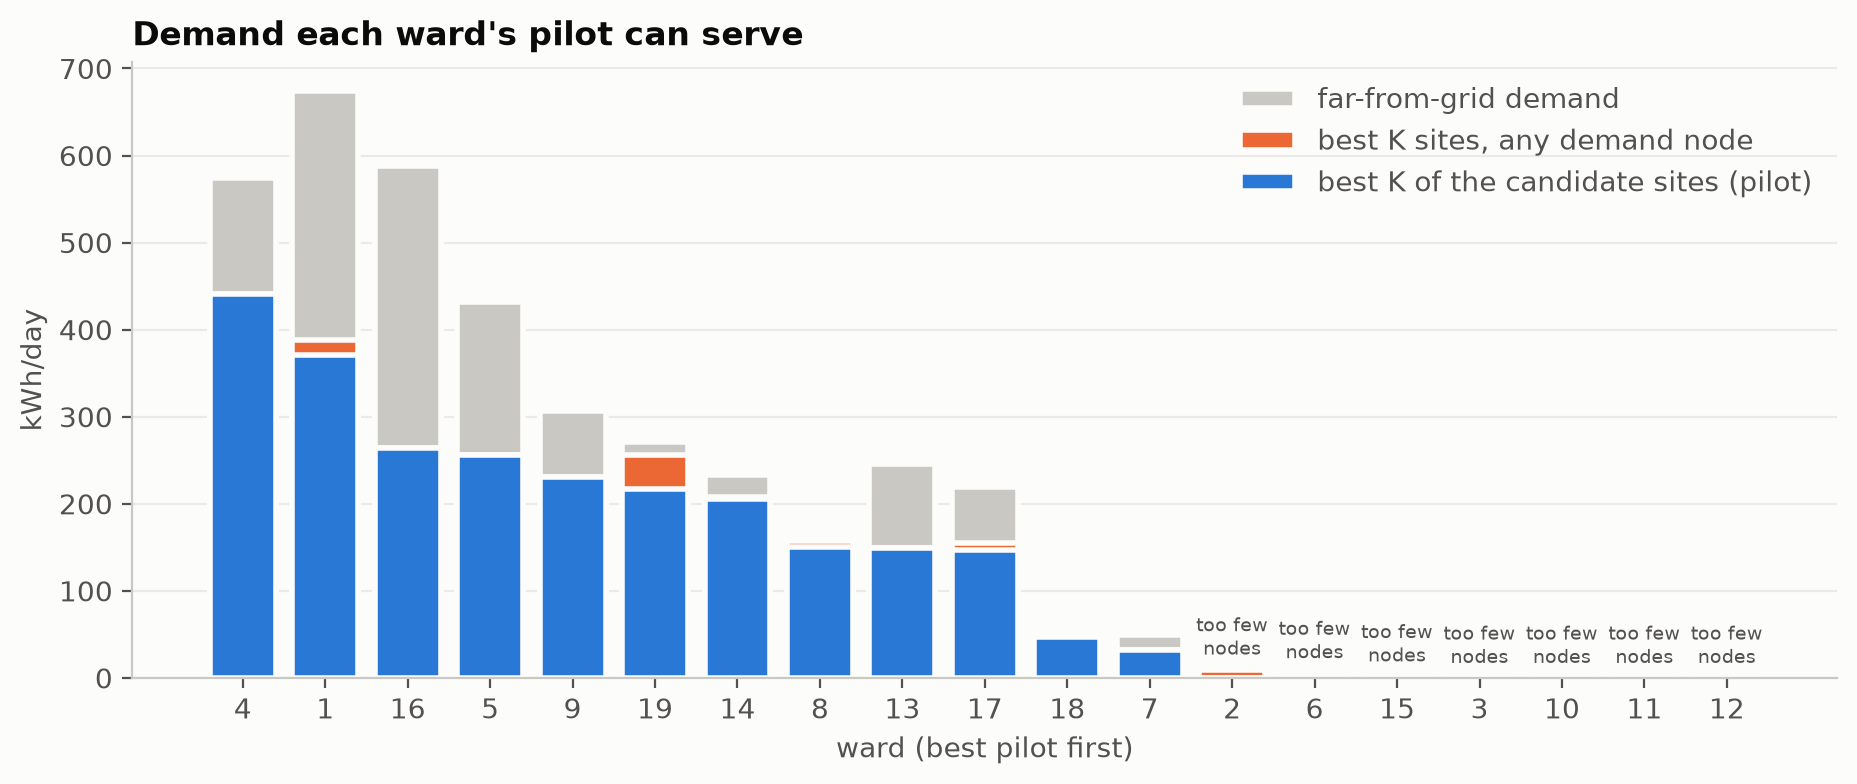

In [4]:
viz.plot_ward_screening(screen)
plt.show()

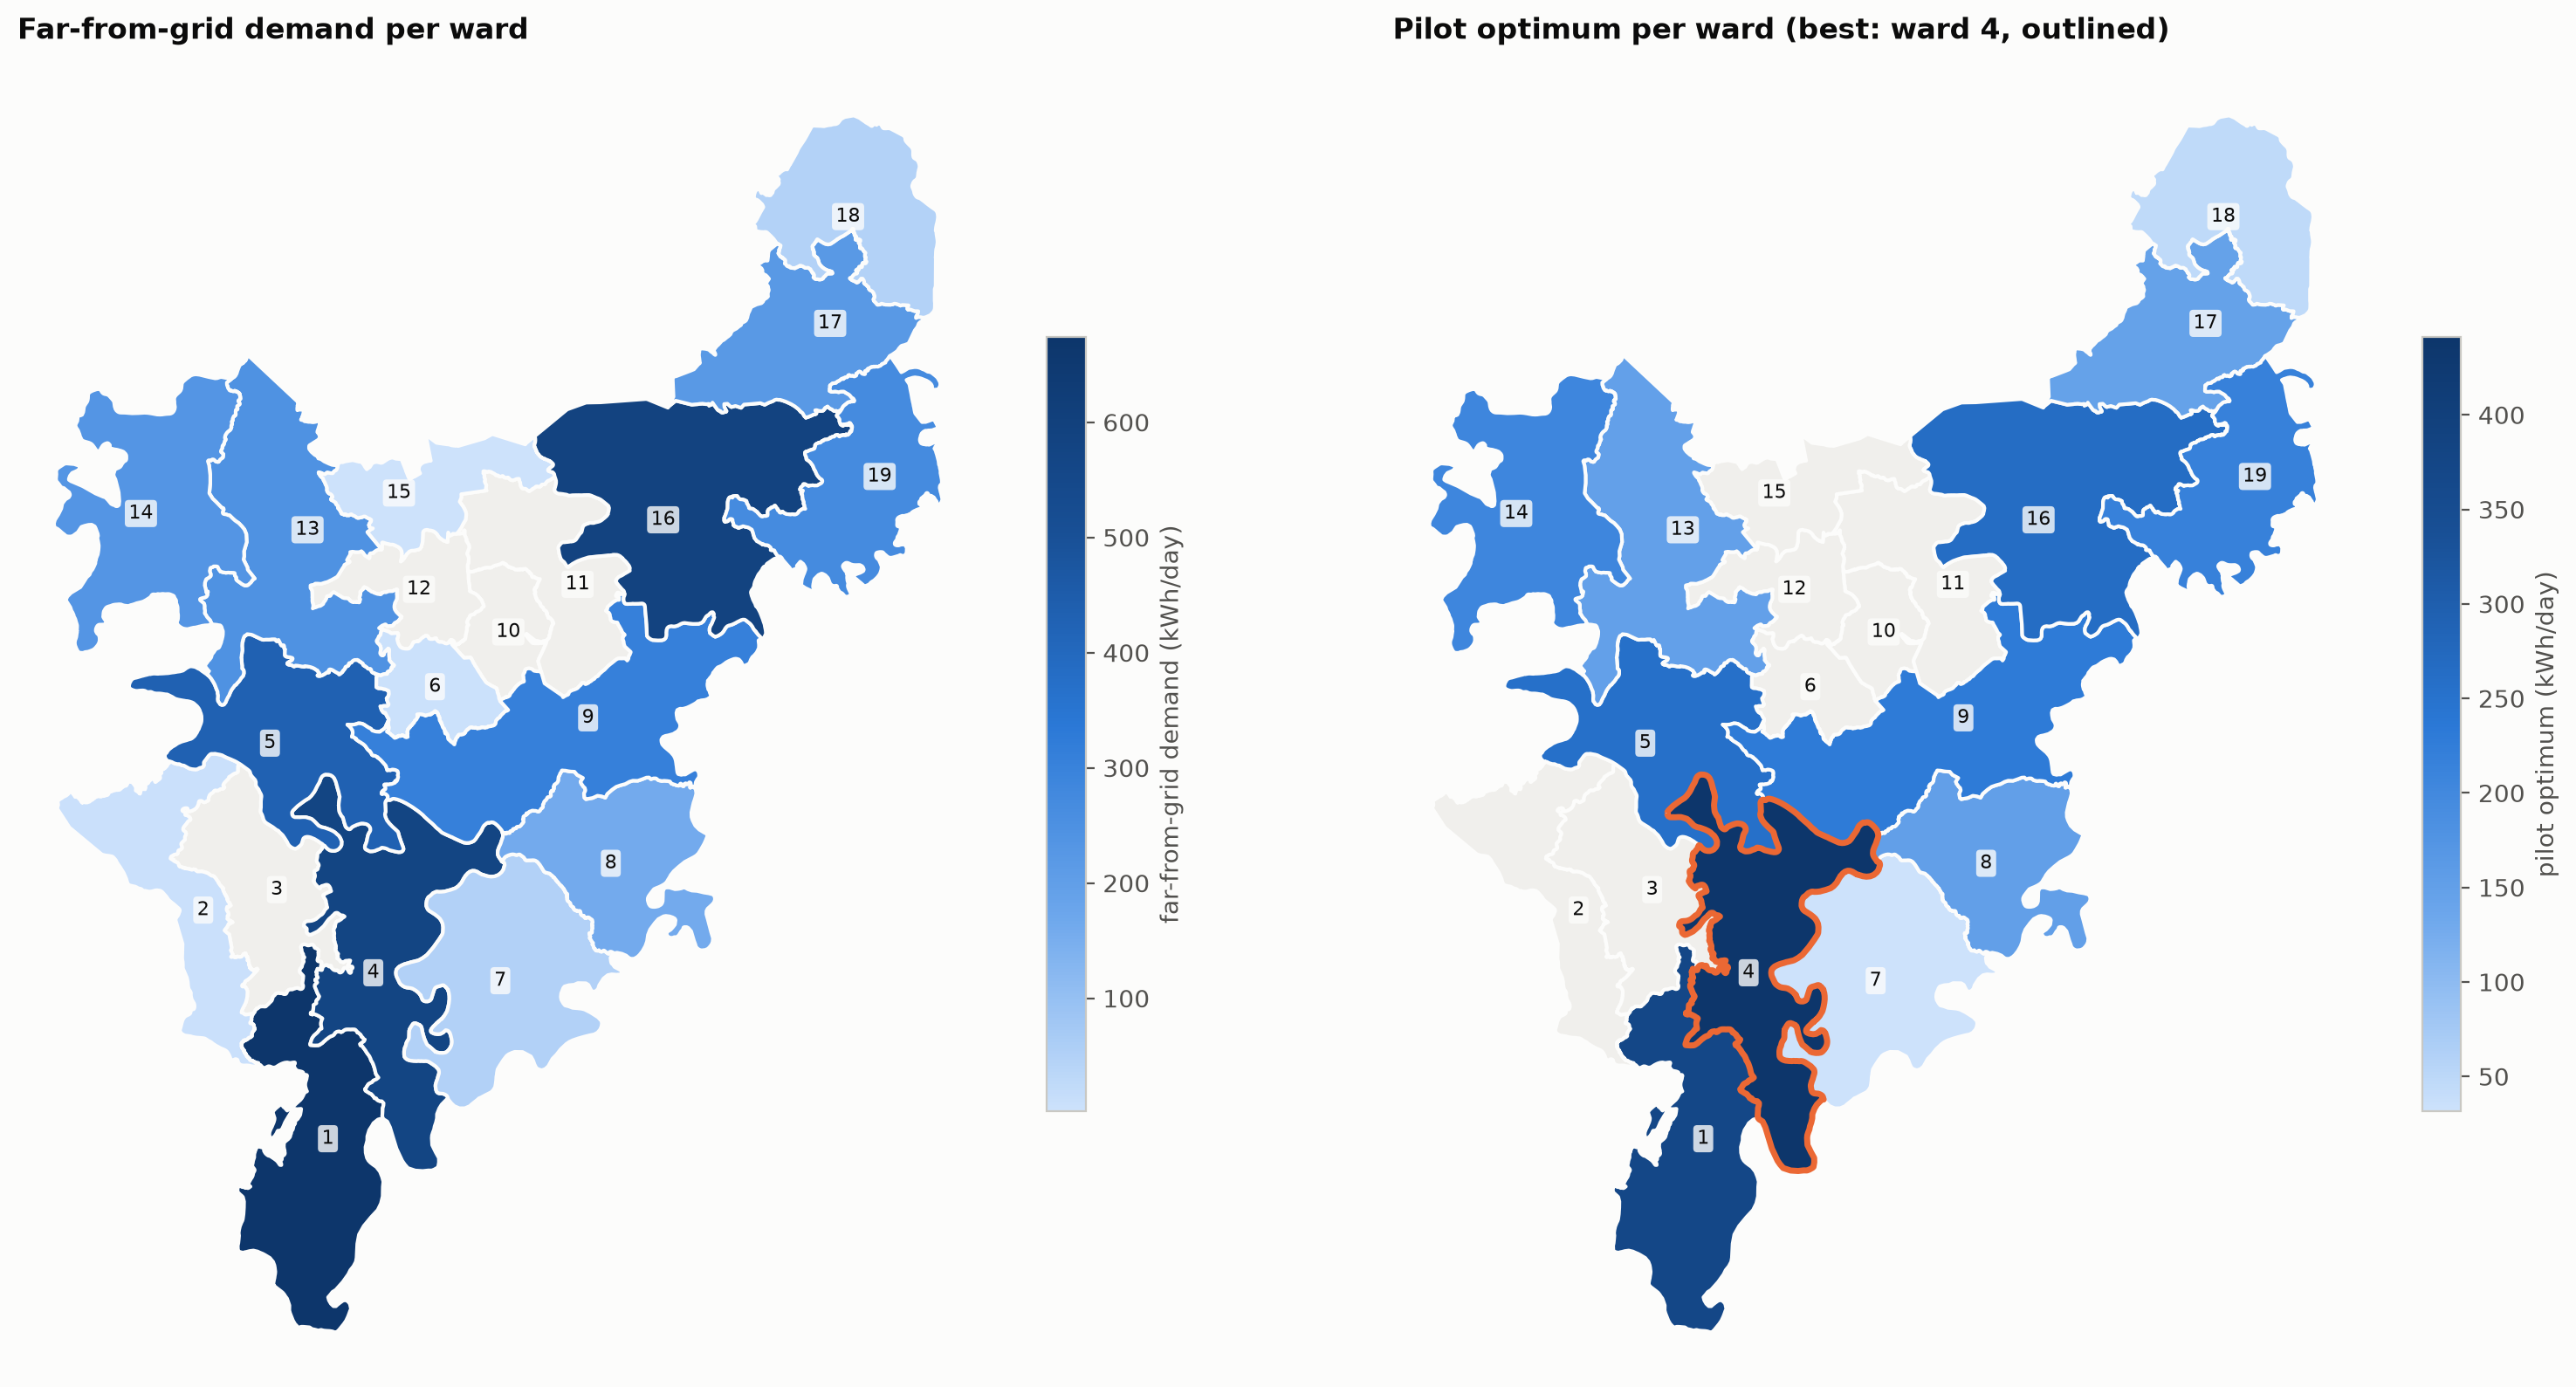

In [5]:
best_ward = int(screen.index[0])
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
viz.plot_ward_choropleth(muni.wards, screen["far_demand"].where(screen["far_demand"] > 0),
                         "far-from-grid demand (kWh/day)", "Far-from-grid demand per ward", ax=axes[0])
viz.plot_ward_choropleth(muni.wards, screen["pilot_served"], "pilot optimum (kWh/day)",
                         f"Pilot optimum per ward (best: ward {best_ward}, outlined)",
                         highlight=best_ward, ax=axes[1])
plt.tight_layout()
plt.show()

## 2. Is the ward a good test for a quantum solver?

Serving the most demand is not the only consideration. A ward also makes a better
demo when:
- **greedy is not optimal** (`greedy_gap > 0`). If adding the best site one at a time
  already finds the optimum, the problem is too easy to show anything.
- **the QUBO optimum matches the exact optimum** (`qubo_served == pilot_served`). The
  pairwise QUBO can only find the true best plan in wards where that holds.
- **the candidate gap is small**, so the qubit budget does not throw away much of the
  ward's potential.

In [6]:
ready = screen[screen["pilot_ready"]].copy()
ready["qubo_exact"] = np.isclose(ready["qubo_served"], ready["pilot_served"])
ready[["pilot_served", "greedy_served", "greedy_gap", "qubo_served", "qubo_exact", "candidate_gap", "rank"]]

,pilot_served,greedy_served,greedy_gap,qubo_served,qubo_exact,candidate_gap,rank
ward,,,,,,,
4,441.12,413.75,0.06,441.12,True,0.00,1
1,371.12,361.25,0.03,371.12,True,0.05,2
16,264.00,253.00,0.04,264.00,True,0.00,3
5,256.25,256.25,0.00,256.25,True,0.00,4
9,230.25,219.38,0.05,230.25,True,0.00,5
19,216.88,209.50,0.03,216.88,True,0.15,6
14,205.38,205.38,0.00,205.38,True,0.01,7
8,150.25,141.25,0.06,150.25,True,0.05,8
13,149.50,149.50,0.00,149.50,True,0.00,9


## 3. Does the ranking survive different assumptions?

The service radius and the grid-distance cut-off are both rough estimates. Each column
below re-runs the full screen with one combination of the two. Each cell is the ward's
rank (1 = best pilot), and blank cells are wards that are not pilot-ready under that
config. A ward that stays near the top across the grid is a safe choice.

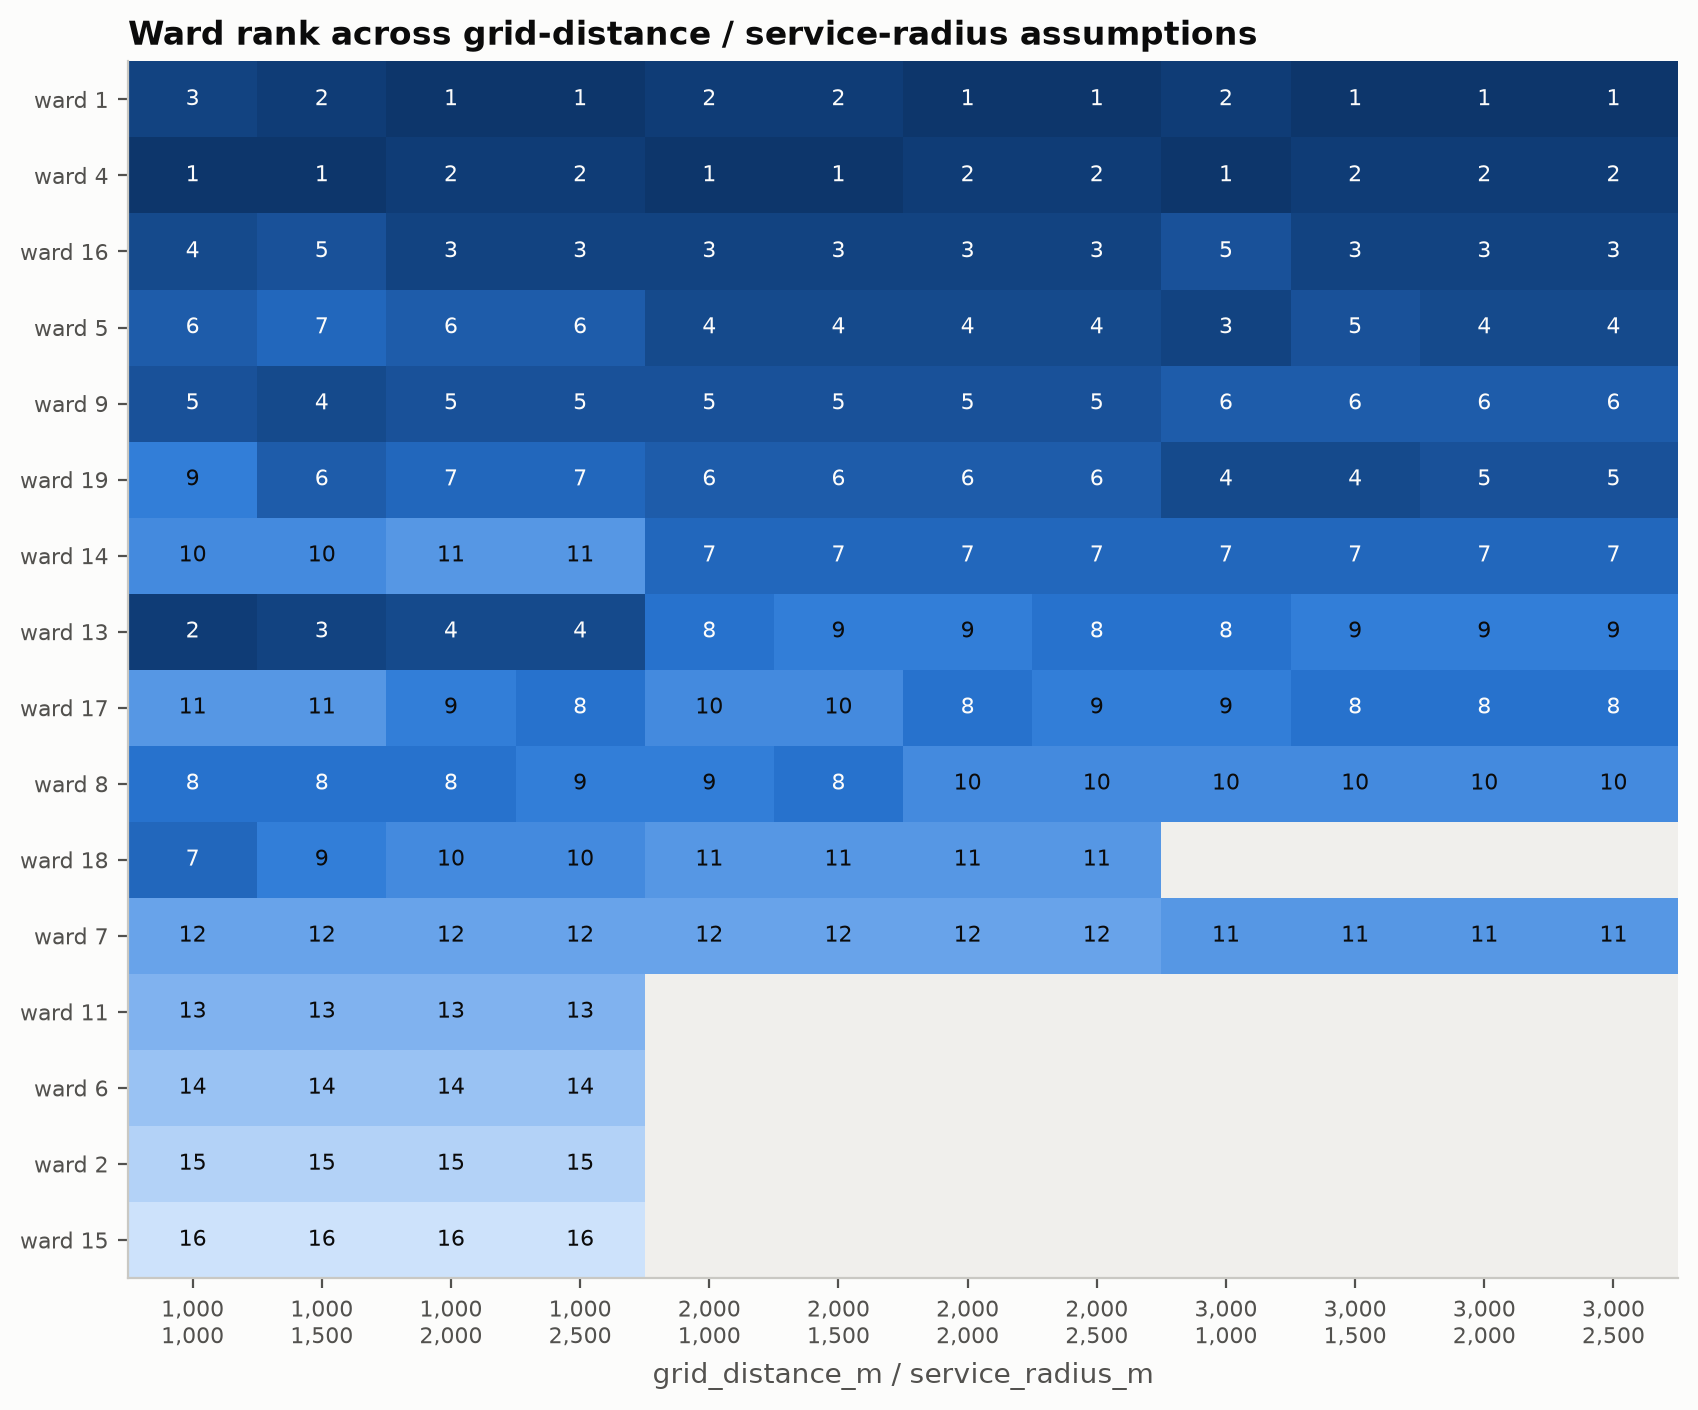

,times_best,times_top3,median_rank,worst_rank
ward,,,,
1,7,12,1.0,3.0
4,5,12,2.0,2.0
16,0,9,3.0,5.0
13,0,2,8.0,9.0
5,0,1,4.0,7.0
9,0,0,5.0,6.0


In [7]:
RADII = [1_000, 1_500, 2_000, 2_500]
GRID_DISTANCES = [1_000, 2_000, 3_000]
ranks = rank_sweep(muni, cfg, grid_distance_m=GRID_DISTANCES, service_radius_m=RADII)

viz.plot_rank_heatmap(ranks, title="Ward rank across grid-distance / service-radius assumptions")
plt.show()

summary = pd.DataFrame({
    "times_best": (ranks == 1).sum(axis=1),
    "times_top3": (ranks <= 3).sum(axis=1),
    "median_rank": ranks.astype(float).median(axis=1),
    "worst_rank": ranks.astype(float).max(axis=1),
}).sort_values(["times_best", "times_top3", "median_rank"], ascending=[False, False, True])
summary.head(6)

## 4. Ignoring ward boundaries

The pilot is limited to one ward, but the municipality as a whole could build more. Here
the MILP picks the best `n_total` sites from every far-from-grid demand node in
Ntabankulu, and a site may serve demand across a ward boundary. Wards that get several
sites hold the strongest demand clusters. Demand within reach of more than one site is
credited to the nearest one.

In [8]:
N_TOTAL = 10
alloc = allocate_sites(muni, cfg, N_TOTAL)
far = muni.far_nodes(cfg)
total_served = alloc["serves_kwh_day"].sum()
print(f"{N_TOTAL} sites serve {total_served:.0f} of {far['demand_kwh_day'].sum():.0f} kWh/day "
      f"of far-from-grid demand in the municipality")
by_ward = alloc.groupby("WardNo").agg(sites=("serves_kwh_day", "size"), serves_kwh_day=("serves_kwh_day", "sum"))
by_ward.sort_values("serves_kwh_day", ascending=False)

10 sites serve 1319 of 3818 kWh/day of far-from-grid demand in the municipality


,sites,serves_kwh_day
WardNo,,
4,2,365.12
1,2,298.88
5,2,196.62
19,1,128.88
14,1,114.38
16,1,109.25
9,1,105.50


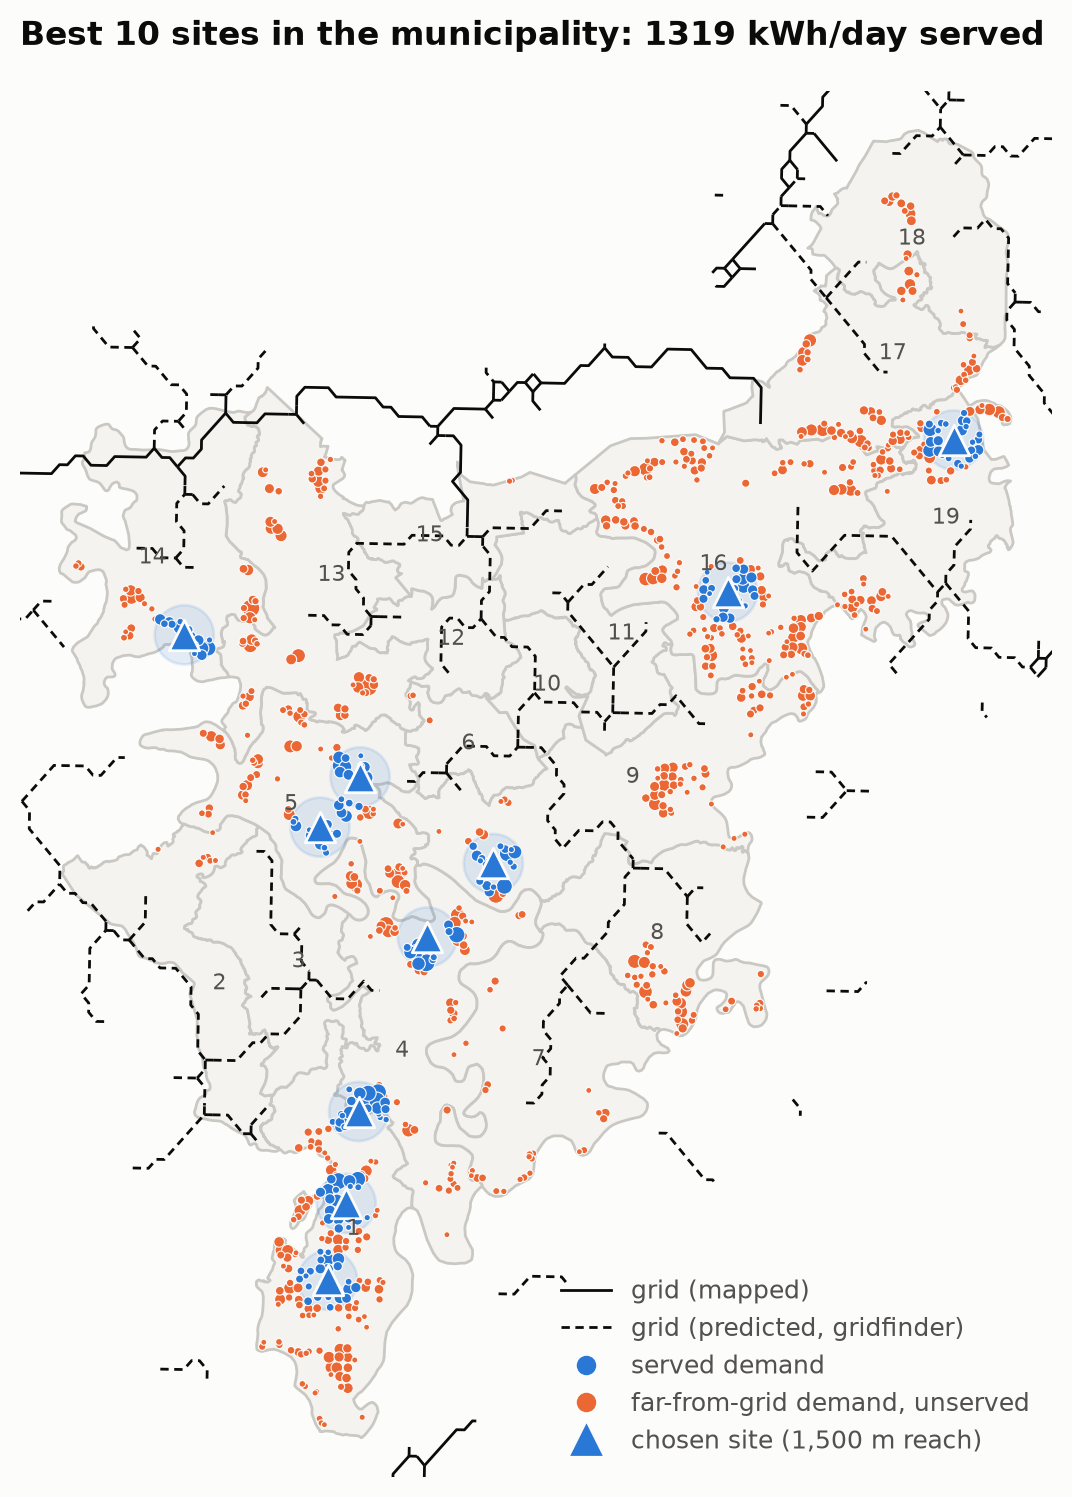

In [9]:
viz.plot_allocation(muni.wards, muni.grid, far, alloc, cfg.service_radius_m,
                    title=f"Best {N_TOTAL} sites in the municipality: {total_served:.0f} kWh/day served")
plt.show()

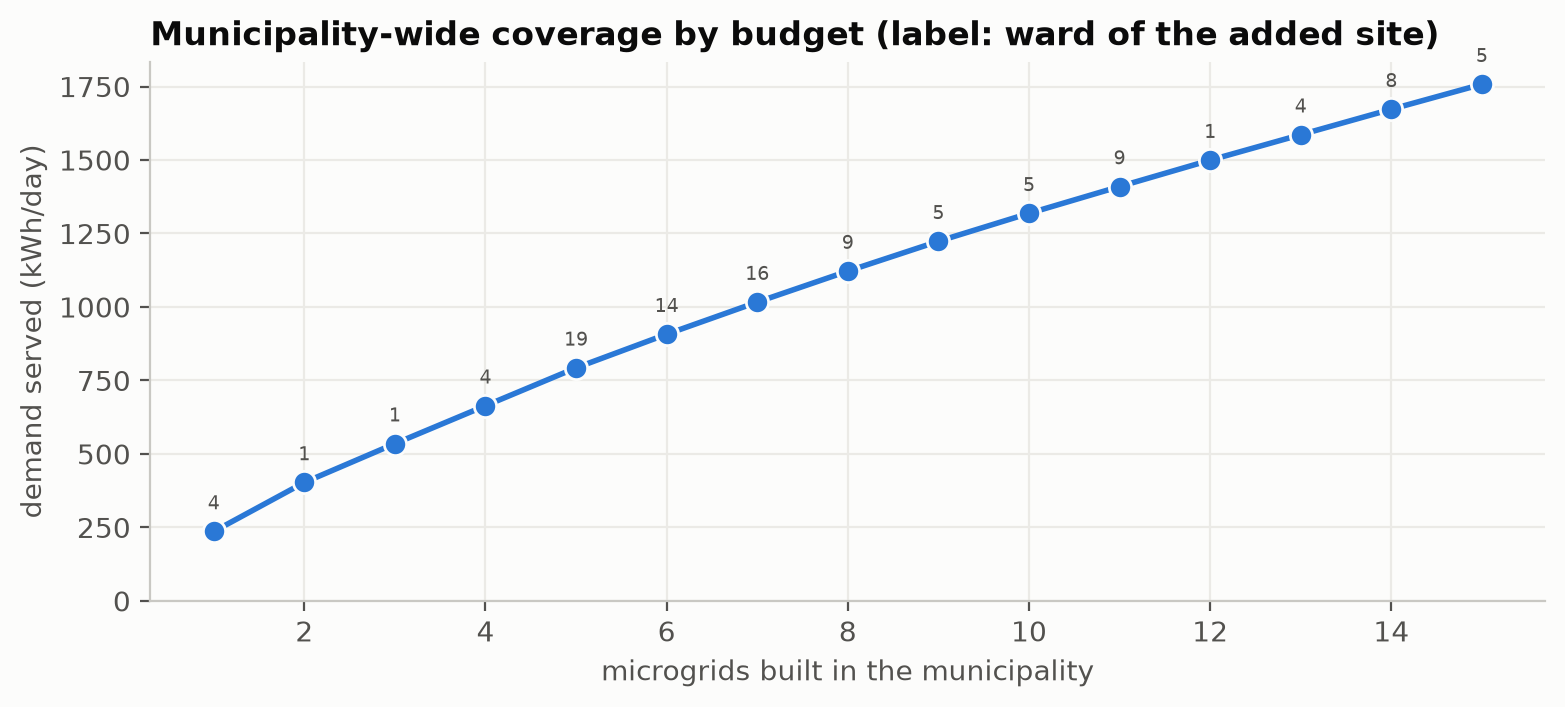

In [10]:
# Each extra site serves less than the one before it. Labels show which ward hosts the
# newly added site (the MILP re-optimises every site at each budget, so earlier sites can move).
budgets = range(1, 16)
served_by_budget, new_ward = [], []
prev = set()
for n in budgets:
    a = allocate_sites(muni, cfg, n)
    served_by_budget.append(a["serves_kwh_day"].sum())
    wards_now = list(a["WardNo"])
    added = pd.Series(wards_now).value_counts().sub(pd.Series(list(prev)).value_counts(), fill_value=0)
    new_ward.append(", ".join(str(w) for w in added[added > 0].index))
    prev = wards_now

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(list(budgets), served_by_budget, color=viz.SERVED, marker="o", markersize=8, markeredgecolor=viz.SURFACE)
for n, s, w in zip(budgets, served_by_budget, new_ward):
    ax.annotate(w, (n, s), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=7,
                color=viz.INK_SECONDARY)
ax.set_xlabel("microgrids built in the municipality")
ax.set_ylabel("demand served (kWh/day)")
ax.set_ylim(bottom=0)
ax.set_title("Municipality-wide coverage by budget (label: ward of the added site)")
plt.show()

## 5. Recommendation

The ward with the best pilot optimum at the pilot config, next to the hand-picked ward,
both shown with their optimal selection.

**Reading the results at the default config (2 km cut-off, 1.5 km radius, K = 3 of 12).**
- **Ward 4** has the best pilot: about 440 kWh/day, roughly twice ward 19. It ranks 1st
  or 2nd in every config tested, greedy is about 6% short of the optimum, and the QUBO
  optimum is exact. It is the recommended pilot ward.
- **Ward 1** is the close alternative. It has the largest far-from-grid demand pool and
  overtakes ward 4 at a 2 km radius or more (7 of 12 configs). It never ranks below 3rd.
- **Ward 19** (the current choice) ranks about 6th. It loses 15% of its potential to the
  candidate-site restriction, the largest loss of any ward.
- Wards 3, 10, 11 and 12 have no settlements beyond 2 km of the gridfinder grid, so
  they cannot host a pilot.

The municipality-wide MILP agrees: the first sites go to wards 4 and 1.

/Users/yakhals/projects/quackathon/.venv/lib/python3.14/site-packages/geopandas/plotting.py:1408: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  return plot_dataframe(data, *args, **kwargs)
/Users/yakhals/projects/quackathon/.venv/lib/python3.14/site-packages/geopandas/plotting.py:1408: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  return plot_dataframe(data, *args, **kwargs)


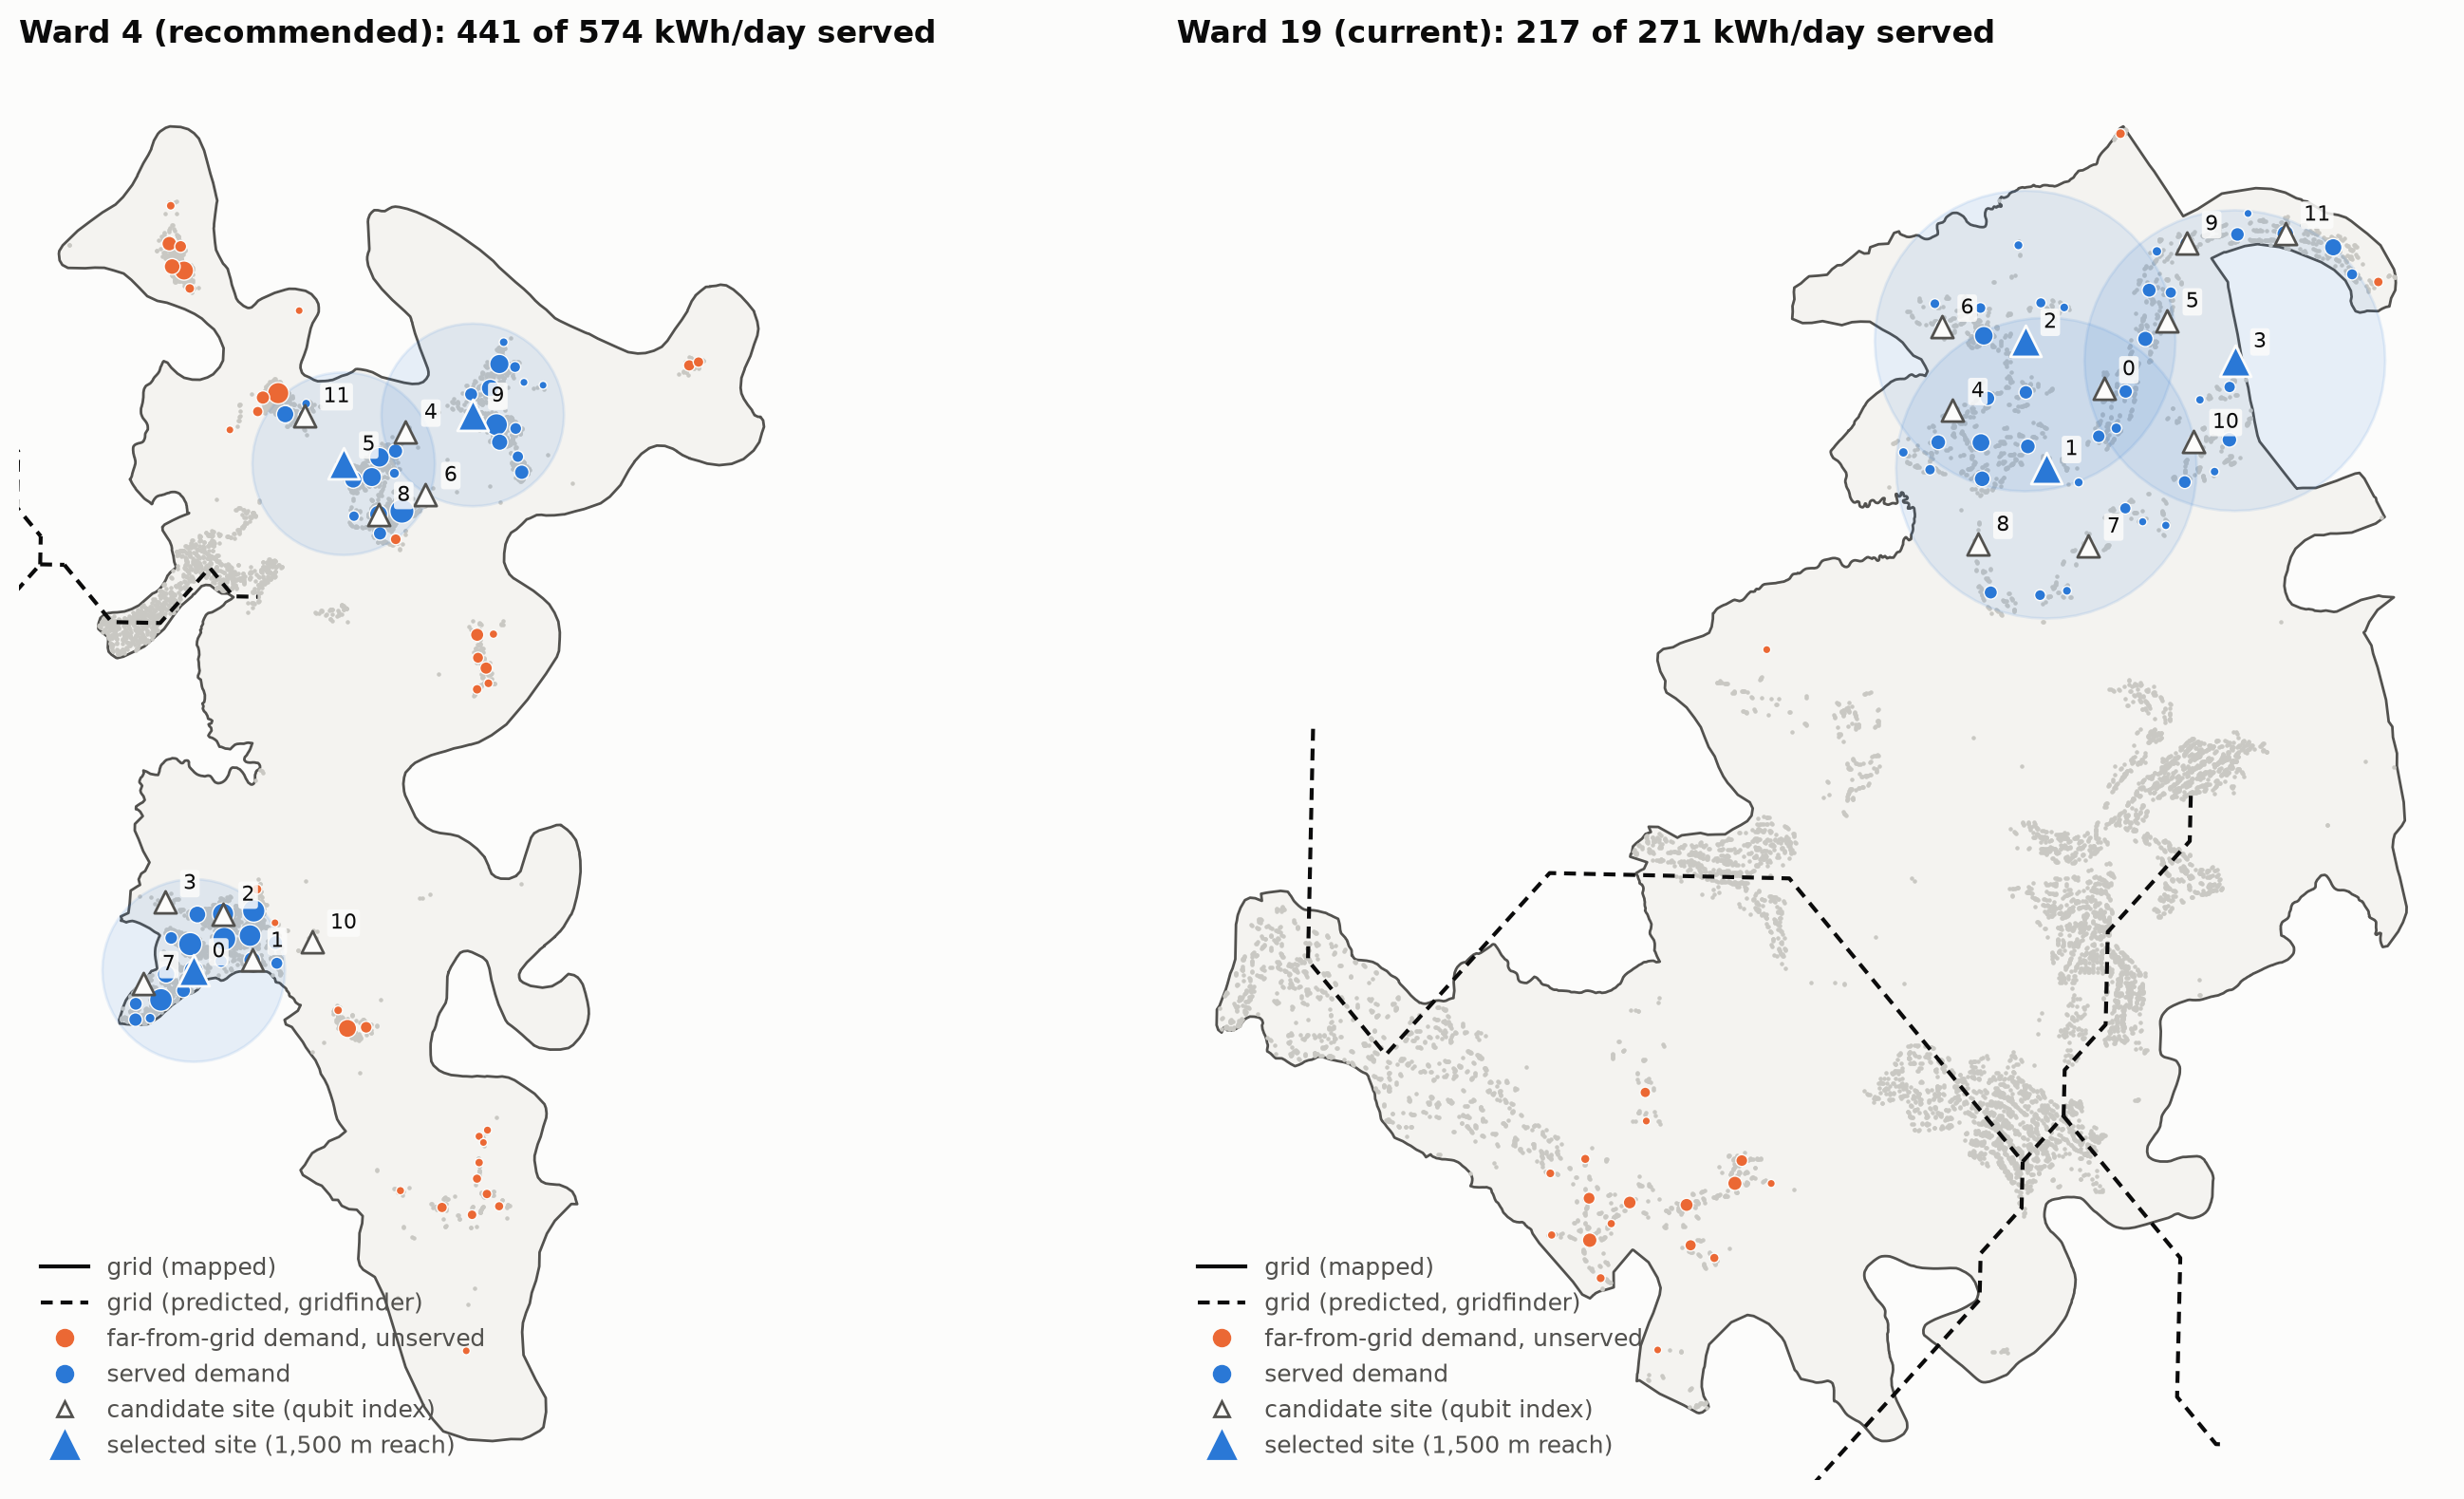

Ward 4: pilot serves 441 kWh/day (77% of its far demand), rank 1 in 5 of 12 configs, greedy gap 6.2%
Ward 19: pilot serves 217 kWh/day (80%), rank 6, greedy gap 3.4%

In pilot.ipynb:  cfg = PilotConfig(ward_no=4, ...)


In [11]:
best = build_pilot(replace(cfg, ward_no=best_ward))
current = build_pilot(replace(cfg, ward_no=CURRENT_WARD))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for pilot, ax, tag in [(best, axes[0], "recommended"), (current, axes[1], "current")]:
    x = solve_exact(pilot.problem).x
    viz.plot_pilot(pilot, x, ax=ax, title=f"Ward {pilot.cfg.ward_no} ({tag}): "
                   f"{pilot.problem.served_demand(x):.0f} of {pilot.problem.demand.sum():.0f} kWh/day served")
plt.tight_layout()
plt.show()

b, c = screen.loc[best_ward], screen.loc[CURRENT_WARD]
print(f"Ward {best_ward}: pilot serves {b['pilot_served']:.0f} kWh/day ({b['pilot_share']:.0%} of its far demand), "
      f"rank 1 in {summary.loc[best_ward, 'times_best']} of {ranks.shape[1]} configs, greedy gap {b['greedy_gap']:.1%}")
print(f"Ward {CURRENT_WARD}: pilot serves {c['pilot_served']:.0f} kWh/day ({c['pilot_share']:.0%}), "
      f"rank {c['rank']}, greedy gap {c['greedy_gap']:.1%}")
print(f"\nIn pilot.ipynb:  cfg = PilotConfig(ward_no={best_ward}, ...)")